# Introduction to PCA

**Overview**
This exercise contains two parts. The exercise is about implementing and applying PCA to a database consisting of face shapes. The exercise lays the foundations for assignment 2. **Part 2 of this exercise is intented for next week**.


**Important**
This exercise and the **in-class** exercise are very similar, but use different datasets. In this exercise you should use your implementation from the in-class exercise, but we advise that you actually go through the steps again to understand the algorithm and not only the results.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#implementation">Task 1: Dimensionality reduction</a>
            </li>
            <li>
            <a href="#implementation2">Task 2: Dimensionality reduction</a>
            </li>
            <li>
            <a href="#implementation3">Task 3: Dimensionality reduction</a>
            </li>
            <li>
            <a href="#implementation4">Task 4: Mapping between spaces</a>
            </li>
            <li>
            <a href="#implementation5">Task 5: Dimensionality reduction</a>
            </li>
            <li>
            <a href="#eval2">Task 6: Evaluating reconstruction error</a>
            </li>
            <li>
            <a href="#eval">Task 7: Reflection on reconstruction</a>
            </li>
        </ul>
    </div>
</article>

# Part 1
## Data
The dataset used for the assigment consists of 120 landmarks (2D points) of faces (data space). A face consists of 73 (x,y)-coordinate pairs, i.e. 146 featues in total.
The following cell imports the necessary libraries, loads the data and uses the function `plot_many_faces`
 to  visualize 6 faces.


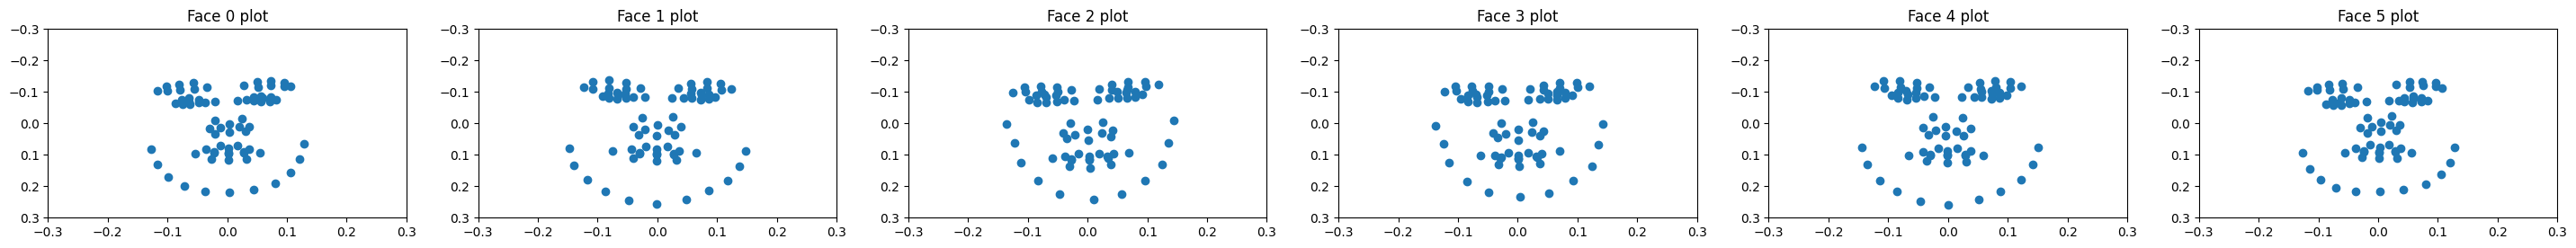

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pca_utils import *

path = './db'
shapes, images = face_shape_data(path)
plot_many_faces(shapes[:6])

## Implementing PCA
An application of principal component analysis is about finding a linear transformation (projection)
that reduces the number of dimensions used to represent the data while
retaining a certain proportion of the total variation. 
This exercise will use the following definitions:
Let the covariance matrix be:

$$
\Sigma = \frac{1}{n-1} X^{\top} X
$$
Let $X$ $\in \mathbb{R}^{N \times D}$ be the data matrix, $C$ $\in \mathbb{R}^{D \times D}$ the covariance matrix of $X$, and $V$ $\in \mathbb{R}^{D \times D}$ the matrix of eigenvectors of $C$ where each eigenvector is placed in the columns of $V$:

$$

{V} = \begin{bmatrix} | & | & & | \\ {v}_1 & {v}_2 & \cdots & {v}_D  \\ | & | & & | \end{bmatrix}.

$$
Assume, the eigenvectors ${v}_i$ are sorted according to their eigenvalues $\lambda_i$. The eignevalue of the covariance matrix $\lambda_i$ gives the variance along the eignevector directions. The sum of all eigenvalues $\lambda^{(1)}+\dots+\lambda^{(D)}$ gives the total variance of the data. 
(1) **Proportional variance** is the proportion of the total variance explained by a single principal component. 

$$\frac{\lambda^{(i)}}{\lambda^{(1)} + \dots + \lambda^{(D)}}$$
(2) **Cumulative variance** is the cumulative proportion of the total variance explained by the first $k$ components.

$$\frac{\lambda^{(1)} + \dots + \lambda^{(k)}}{\lambda^{(1)} + \dots + \lambda^{(D)}}$$
Define $\Phi$, as the $D\times D$ matrix of the all eigenvectors of $V$:

$$

{\Phi} = \begin{bmatrix} | & | & & | \\ {v}_1 & {v}_2 & \cdots & {v}_D \\ | & | & & | \end{bmatrix}.

$$
Define $\Phi_k$, as the $D\times k$ matrix of the first $k$ eigenvectors of $V$:

$$

{\Phi_k} = \begin{bmatrix} | & | & & | \\ {v}_1 & {v}_2 & \cdots & {v}_k \\ | & | & & | \end{bmatrix}.

$$
The column vectors of ${\Phi_k}$ constitute the orthonormal basis of the latent space. ${\Phi_k}$ can be used to transform data points between the data space and the latent space. The mapping of a point $x$ from data space to latent space is given by:

$$ 
\mathbf{a} = \mathbf{\Phi_k}^\top(\mathbf{x}-\mathbf{\mu}),
$$
and back into data space:

$$
x  = \mathbf{\Phi_k} \mathbf{a} + \mathbf{\mu}
$$
If $k = D$ (keeping all dimensions) will result in no data loss because it is a change of basis in the same $D$ dimensions. Retaining  $k<D$  principal components and consequently discarding the remaining  $r = D - k$  components, it is effectively assumed that these $r$ components do not contain significant information, e.g. noise. The percentage of the total variance that is removed is given by:

$$\frac{\lambda^{(D-k)} + \dots + \lambda^{(D)}}{\lambda^{(1)} + \dots + \lambda^{(D)}}$$
where  $\lambda^{(i)}$  are the eigenvalues sorted in descending order $( \lambda^{(1)} \geq \lambda^{(2)} \geq \dots \geq \lambda^{(D)} )$.
That is there will be a _reconstruction error_ $\epsilon = x - \tilde{x}$,  by first mapping the data $x$ to latent space by $\mathbf{a} = \mathbf{\Phi_k}^\top(\mathbf{x}-\mathbf{\mu})$ and then  back to data space by $\tilde{x}  = \mathbf{\Phi_k} \mathbf{a} + \mathbf{\mu}$.
The next task is about implementing PCA and transforming data between data space and latent space.

---
**Task 1 (medium): Dimensionality reduction👩‍💻**
1. **Complete PCA:** Following the comments in the function template, complete the `get_principle_components`
 function below to calculate and return all principle components of the dataset. **Make sure to center the samples (subtract the mean before calculating the covariance matrix)**.

2. **Calculate variance:** Complete the `variance_proportion_plot`
 function according to the comments in the function template to calculate the _proportional_ and _cumulative_ variance. The function includes code to plot both on a single graph. Once the function is complete, generate the plot to display the _proportional_ and _cumulative_ variances.



---

/Users/jonasson/.pyenv/versions/3.12.2/envs/intro_to_ml/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/jonasson/.pyenv/versions/3.12.2/envs/intro_to_ml/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


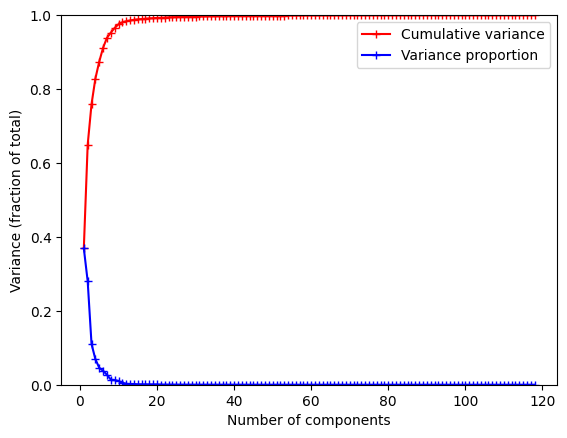

In [2]:
## 1
import numpy as np

def get_principle_components(X):
    """Calculates principle components for X.

    Args:
        X: The dataset. An NxD array were N are the number of samples and D are
        the number of features.

    Returns:
        Tuple (components, eigenvalues, mu) where components is a DxD matrix of
        principle components, eigenvalues is a D-element vector of
        corresponding eigenvalues, and mu is a D-element array containing the mean
        vector.
    """
    mu = X.mean(axis=0) # mean over the data point axis to get mean of each feature
    norm = X - mu # subtract mean from all points to normalize around 0
    cov = 1 / (norm.shape[0] - 1) * np.matmul(norm.T, norm) # Calculate covariance as per above formula
    ##cov = np.cov(norm)

    # NOTE: to get eigenvectors and eigenvalues without complex representation, we could use sympy, says stack overflow. For future reference. 

    e_val, e_vec = np.linalg.eig(cov) # use numpy library to get eigenvalues and eigenvectors
    # sorting in decreasing order
    temp = list(zip(list(e_val), list(e_vec)))
    temp.sort(reverse= True, key=lambda x : x[0])
    e_val, e_vec = np.array([n[0] for n in temp]), np.array([n[1] for n in temp])
    return (e_vec, e_val, mu)
    
## 2 

def variance_proportion_plot(pc_values, max=1):
    """
    Plots the cumulative and individual variance proportions for principal components.

    Args:
        pc_values: 1D array of eigenvalues representing the variance explained by each principal component.
        max: Maximum cumulative variance proportion to display (between 0 and 1).

    Returns:
        None. Displays a plot of cumulative and individual variance proportions.
    """
    # Calculate total variance, cumulative variance, and individual variance proportions
    total = pc_values.sum()
    cumulative = np.array([sum(pc_values[:i+1]) for i in range(len(pc_values))])
    proportion = cumulative / total
    # Individual variance proportion for each component
    each = pc_values / total
    

    # Find the minimum number of components required to reach the desired cumulative variance
    max_idx = np.argwhere(proportion >= max - 1e-7)[0, 0]
    
    # Set the x-axis values (number of components) up to the determined threshold
    x = np.arange(1, max_idx + 1, 1)

    # Create the plot
    plt.figure()
    plt.xlabel('Number of components')
    plt.ylabel('Variance (fraction of total)')
    
    # Plot cumulative variance proportion and individual variance proportion
    plt.plot(x, proportion[:max_idx], 'r-+', label='Cumulative variance')
    plt.plot(x, each[:max_idx], 'b-+', label='Variance proportion')

    # Set the y-axis limit and add a legend
    plt.ylim(0, 1)
    plt.legend(['Cumulative variance', 'Variance proportion'])
    
    # Display the plot
    plt.show()



comp, val, mu = get_principle_components(shapes)
#print(comp[:1], val[:1], mu[:1])
variance_proportion_plot(val)

In [3]:
# SymPy way (runs forever, I let it go after 2min)
import sympy as sp

mu_sp = shapes.mean(axis=0) # mean over the data point axis to get mean of each feature
norm_sp = shapes - mu_sp # subtract mean from all points to normalize around 0
cov_sp = 1 / (norm_sp.shape[0] - 1) * np.matmul(norm_sp.T, norm_sp) # Calculate covariance as per above formula

# NOTE: to get eigenvectors and eigenvalues without complex representation, we could use sympy, says stack overflow. For future reference. 

M = sp.Matrix(cov_sp)
M.eigenvects()

[(0.00317015997970231,
  1,
  [Matrix([
   [   0.0254205595573105],
   [    0.125677827821045],
   [-0.000666514695122696],
   [    0.111739420727029],
   [  -0.0300795951504659],
   [   0.0612949025474357],
   [   -0.025678581520203],
   [   0.0489182173415519],
   [  0.00187377603120133],
   [   0.0475499762061696],
   [  -0.0263294269623754],
   [   0.0491826424874817],
   [  -0.0272391338518899],
   [   0.0735783862674329],
   [ 0.000349537616432943],
   [     0.10978147801044],
   [  -0.0287020545013415],
   [    0.142816673558763],
   [ -0.00693723358853457],
   [    0.110291884399755],
   [   0.0205353946811171],
   [   0.0723187021981334],
   [   0.0352956540527712],
   [   0.0572679815016008],
   [   0.0286710274715882],
   [   0.0405469147905289],
   [   0.0359157020184634],
   [   0.0546350344156668],
   [   0.0211437760354189],
   [   0.0782230906121508],
   [ -0.00573839881847762],
   [    0.115957893298112],
   [   0.0482872595728672],
   [   0.0806089185571982],
   [   0

# PCA Exercises

---
**Task 2 (medium): Dimensionality reduction👩‍💻💡📽️**
1. What is the total variance of the dataset?
2. What is the variance and percentage explained by the first component?
3. What is the variance and percentage explained by the first $k$ components?    - $k = 5$
    - $k = 10$
    - $k = 20$




---

In [4]:
# Write your reflections here...
print(f"Total Veriance is: {float(val.sum())}")
print(f"First Component has: Variance - {float(val[0])}; Proportional Variance - {round(float(val[0]) / float(val.sum())*100,2)}%")
print(f"First 5 components have: Variance - {float(sum(val[:5]))}; Proportional Variance - {round(float(sum(val[:5])) / float(val.sum())*100,2)}%")
print(f"First 10 components have: Variance - {float(sum(val[:10]))}; Proportional Variance - {round(float(sum(val[:10])) / float(val.sum())*100,2)}%")
print(f"First 15 components have: Variance - {float(sum(val[:15]))}; Proportional Variance - {round(float(sum(val[:15])) / float(val.sum())*100,2)}%")

Total Veriance is: 0.008592833338490995
First Component has: Variance - 0.0031701599797023215; Proportional Variance - 36.89%
First 5 components have: Variance - 0.0075119968860105765; Proportional Variance - 87.42%
First 10 components have: Variance - 0.008381496764050976; Proportional Variance - 97.54%
First 15 components have: Variance - 0.008494318819690374; Proportional Variance - 98.85%


/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_28407/4155378555.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  print(f"Total Veriance is: {float(val.sum())}")
/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_28407/4155378555.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  print(f"First Component has: Variance - {float(val[0])}; Proportional Variance - {round(float(val[0]) / float(val.sum())*100,2)}%")
/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_28407/4155378555.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  print(f"First 5 components have: Variance - {float(sum(val[:5]))}; Proportional Variance - {round(float(sum(val[:5])) / float(val.sum())*100,2)}%")
/var/folders/5p/hd3qyvgs2yj3fc69b966hnfc0000gn/T/ipykernel_28407/4155378555.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  print(f"First 10 components have: Va


---
**Task 3 (medium): Dimensionality reduction👩‍💻📽️**
1. Explain why the matrix $V$ is orthonormal? 
2. In the cell below, verify that $V$ is orthonormal for your dataset.
3. Calculate the inverse of $V$ and relate it to its transpose. Explain the result.


---

In [6]:
# Write your answer here ...

#1. Because it's made of eigenvectors which are orthogonal to each other (each column describes a different 'axis' of the data)

#2
V = comp
# supress complex representation
#V = np.real(comp)
V_check = np.matmul(V.T, V)

# should have 1s on the diagonal and 0s elsewhere because of the characteristics of the dot product for same and orthogonal vectors

# supress scientific notation, round to two decimal points
np.set_printoptions(suppress=True, precision=2)
print(V_check.diagonal())
print(V[8])

# there seem to be errors related to operations in the complex number space (as indicated by +j).
# overall most values are relatively close to 1s and 0s, so I would consider them as such

[ 1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j
  1.  

In [7]:
# 3

# again, the matrices are not equal (as expected) because they differ in their complex representations
V_inv = np.round(np.linalg.inv(V),2)
V_transpose = np.round(V.T, 2)

print(V_inv, "\n")
print(V_transpose)

# The matrices should be equal as, as shown before, multiplying the matrix with its transpose results in a matrix with 1s on the diagonal
# and 0s elsewhere. This is precisely the definition of the indenity matrix, which is the result of multiplying the inverse with its
# corresponding matrix. Hence, the two should be exactly the same. 

[[ 0.03+0.j    0.13-0.j   -0.  +0.j   ...  0.03+0.j   -0.01-0.j
  -0.13-0.j  ]
 [ 0.02-0.j    0.12-0.j    0.02+0.j   ...  0.01+0.j    0.01+0.j
  -0.04+0.j  ]
 [ 0.01-0.j   -0.11+0.j    0.  +0.j   ... -0.17+0.j   -0.03-0.j
   0.  -0.j  ]
 ...
 [-0.04-0.11j -0.02+0.11j -0.76+0.95j ...  0.28-0.06j -0.14+0.76j
   0.09-0.16j]
 [-0.04-0.j   -0.02+0.j    0.14+0.j   ... -0.2 -0.j    0.58+0.j
   0.17-0.j  ]
 [-0.02-0.j   -0.04+0.j   -0.  -0.j   ... -0.03-0.j   -0.2 -0.j
   0.06-0.j  ]] 

[[ 0.03+0.j    0.13+0.j   -0.  +0.j   ...  0.03+0.j   -0.01+0.j
  -0.13+0.j  ]
 [ 0.02+0.j    0.12+0.j    0.02+0.j   ...  0.01+0.j    0.01+0.j
  -0.04+0.j  ]
 [ 0.01+0.j   -0.11+0.j    0.  +0.j   ... -0.17+0.j   -0.03+0.j
   0.  +0.j  ]
 ...
 [ 0.02-0.03j  0.  -0.j    0.02-0.01j ...  0.  +0.02j  0.3 -0.j
  -0.05+0.08j]
 [ 0.03+0.j   -0.01+0.j    0.02+0.j   ... -0.04+0.j    0.4 +0.j
  -0.05+0.j  ]
 [-0.04+0.j    0.01+0.j   -0.02+0.j   ... -0.06+0.j   -0.21+0.j
  -0.08+0.j  ]]


In [8]:
# 3 supressing complex representation (= loss of data)

V_inv = np.real(np.round(np.linalg.inv(V),2))
V_transpose = np.real(np.round(V.T, 2))

print(V_inv, "\n")
print(V_transpose)

[[ 0.03  0.13 -0.   ...  0.03 -0.01 -0.13]
 [ 0.02  0.12  0.02 ...  0.01  0.01 -0.04]
 [ 0.01 -0.11  0.   ... -0.17 -0.03  0.  ]
 ...
 [-0.04 -0.02 -0.76 ...  0.28 -0.14  0.09]
 [-0.04 -0.02  0.14 ... -0.2   0.58  0.17]
 [-0.02 -0.04 -0.   ... -0.03 -0.2   0.06]] 

[[ 0.03  0.13 -0.   ...  0.03 -0.01 -0.13]
 [ 0.02  0.12  0.02 ...  0.01  0.01 -0.04]
 [ 0.01 -0.11  0.   ... -0.17 -0.03  0.  ]
 ...
 [ 0.02  0.    0.02 ...  0.    0.3  -0.05]
 [ 0.03 -0.01  0.02 ... -0.04  0.4  -0.05]
 [-0.04  0.01 -0.02 ... -0.06 -0.21 -0.08]]


The next questions are about projecting data onto principal components.

---
**Task 4 (medium): Dimensionality reduction👩‍💻📽️**
1. In the cell below choose datapoint $0$ from dataset $X$ and project it onto the following principal components.     - $v_1$
    - $v_2$
    - $v_3$


2. Use the definitions above to construct $\Phi_k$. 
3. Use $\Phi_k$ to project datapoint $0$ from $X$ onto $k \in \{1,2,3\}$ principal components and relate it to your results in question 1.
4. How does this relate to the formula of projecting a datapoint to the latent space:

$$ 
\mathbf{a} = \mathbf{\Phi_k}^\top(\mathbf{x}-\mathbf{\mu}),
$$



---

In [9]:
# I honestly don't understand what else I'm supposed to do than use the formula

Fi_k = V[:,0:3]
a = np.matmul(Fi_k.T, shapes[0] - mu)

print(a)

[ 0.05+0.j  0.01+0.j -0.  +0.j]



---
**Task 5 (medium): Mapping between spaces👩‍💻**
1. Complete the `transform_to_latent_space`
 function that transforms the data from the data space to latent space
( [Equation 1](#eq:trans) ) 


$$
 \mathbf{a} = \mathbf{\Phi}^\top(\mathbf{x}-\mathbf{\mu})
$$
2. Complete the `transform_from_latent_space`
 function that transforms the data from the  latent space to the data space
( [Equation 2](#eq:inv) ).


$$
 \mathbf{x} = \mathbf{\Phi} \mathbf{a} + \mathbf{\mu}
$$

**Tip**
Some of the later tasks will be easier if you return all 146 principle components. You can then create another function for extracting $k$ components to generate $\Phi_k$.


---

In [10]:
def transform_to_latent_space(X, principle_components, mu):
    """Transforms X to an k-dimensional space where k is the number of
    principle_components.

    Args:
        X: The dataset. An NxD array were N are the number of samples and D are
        the number of features.
        principle_components: An Dxk matrix containing the principle
        components.
        mu: A D-element array containing the mean vector.

    Returns:
        A Nxk array describing the transformed data.
    """
    # needed an extra transpose to make the shapes work in the multiplication order given by the formula
    # reason: in the formula for one datapoint the point is a column vector, but in X datapoints are represented as rows 
    # the multiplication is therefore as follows: Dxk, NxD converted to kxD, DxN -> kxN. Final convertion to Nxk as specified.
    return np.matmul(principle_components.T, (X - mu).T).T

def transform_from_latent_space(v, principle_components, mu):
    """Reverses the dimensionality reduction of v, a Nxk matrix where
    k is the number of principle components. The result is a NxD matrix.

    Args:
        v: The transformed (latent space) dataset with size Nxk.
        principle_components: An Dxk matrix containing the principle
        components.
        mu: A D-element array containing the mean vector.

    Returns:
        An NxD array reconstruction of the original feature vectors X.
    """
    # Needed some extra transposes to make the shapes work compared to the formula
    # reason: for the multiplication to succeed wit shapes Dxk, Nxk, we need to pair up the ks -> Dxk, kxN
    # result: DxN matrix. Transpose to make the result NxD as specified.
    t = np.matmul(principle_components, v.T).T 
    return t + mu


---
**Task 6 (medium): Dimensionality reduction👩‍💻📽️**
1. Use the function `transform_to_latent_space`
 to transform $X$ to latent space using all $D$ principal components. Call the transformed data $X_{latent}$.
2. Transform $X_{latent}$ to the data space using the function `transform_from_latent_space`
 and compare to $X$ by calculating the difference.
3. Use the function `transform_to_latent_space`
 to transform $X$ to latents pace using $k$ components. Call the transformed data $X_{latent_k}$. Experiment with different $k$s: $k \in \{1,2, 5, 20\}$.
4. What is the the dimensionality of each datapoint in $X_{latent_k}$?
5. Transform $X_{latent_k}$ to the data space using the function `transform_from_latent_space`
 and compare to $X$ by calculating the difference.
6. For which $k$ is the transformed $X[0]$ closest to the original dataset $X[0]$.


---

In [11]:
X = shapes
X_latent = transform_to_latent_space(X, V, mu)
X_reconstructed = transform_from_latent_space(X_latent, V, mu)
X_difference = X - X_reconstructed
print(146)
print(V.shape)
print(np.real(X_difference))
# 0 valued as expected

for k in [1,2,5,20]:
    V_k = V[:,0:k]
    print(V_k.shape)
    X_latent = transform_to_latent_space(X, V_k, mu)
    X_reconstructed = transform_from_latent_space(X_latent, V_k, mu)
    X_difference = X - X_reconstructed
    print(k, '\n', np.real(X_difference))

# the results are surprisingly small in their difference compared to the full component representation! 
# they still oscilate around 0 even for k=1, and tend to fall quickly as we move to k=20


146
(146, 146)
[[-0.    0.   -0.   ... -0.   -0.01  0.01]
 [ 0.   -0.    0.   ...  0.   -0.    0.01]
 [-0.    0.   -0.   ... -0.   -0.   -0.02]
 ...
 [-0.    0.   -0.   ... -0.    0.   -0.01]
 [-0.    0.   -0.   ... -0.   -0.01  0.  ]
 [-0.   -0.    0.   ...  0.    0.01 -0.01]]
(146, 1)
1 
 [[ 0.01 -0.    0.01 ...  0.01 -0.02  0.03]
 [-0.   -0.01 -0.   ...  0.03  0.    0.04]
 [-0.    0.01  0.   ... -0.04 -0.   -0.06]
 ...
 [-0.   -0.01  0.   ... -0.02  0.01 -0.03]
 [ 0.    0.02  0.   ... -0.   -0.01  0.01]
 [ 0.   -0.01 -0.   ... -0.01 -0.01 -0.02]]
(146, 2)
2 
 [[ 0.01 -0.    0.01 ...  0.01 -0.02  0.03]
 [-0.   -0.01 -0.   ...  0.03  0.    0.04]
 [-0.    0.01  0.   ... -0.04 -0.   -0.05]
 ...
 [-0.   -0.01  0.   ... -0.02  0.01 -0.03]
 [ 0.    0.02  0.   ... -0.   -0.01  0.01]
 [ 0.   -0.01  0.   ... -0.01 -0.01 -0.02]]
(146, 5)
5 
 [[ 0.    0.    0.01 ...  0.01 -0.02  0.03]
 [ 0.   -0.01  0.   ...  0.04  0.    0.04]
 [-0.01  0.01 -0.01 ... -0.05 -0.   -0.06]
 ...
 [-0.01 -0.   -0.01 


**Important**
Only now start on the Mandatory Assignment 2 part 1. The lecture next week will provide the tools for completeing the remaining tasks.

# Part 2
## Reconstruction error
This task involves implementing a method to calculate the reconstruction error and using it to examine the impact of varying the number of principal components. The root mean square error (RMSE) is used for calculating the reconstruction error:

$$RMSE(x, \widetilde{x}) = \sqrt{\frac{1}{N}\sum_i (x_i-\widetilde{x}_i)^2},$$
where $x$, $\widetilde{x}$ are the original and transformed samples
respectively and $N$ is the total number of samples $x_i$.

---
**Task 7 (medium): Evaluating reconstruction error**
1. **Calculate reconstruction error:** Complete the `reconstruction_error`
 function according to the comments in the function template to calculate the reconstruction error.

2. **Plot reconstruction error:** Use the  `reconstruction_error_plot`
 function to plot the reconstruction error for $k=1 .... D$. 



---

/Users/jonasson/.pyenv/versions/3.12.2/envs/intro_to_ml/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/jonasson/.pyenv/versions/3.12.2/envs/intro_to_ml/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


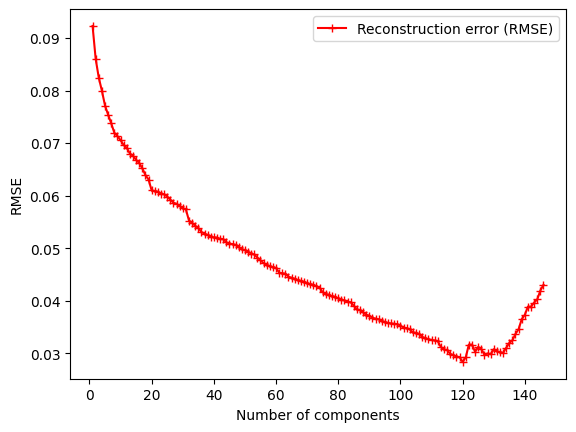

In [12]:
def reconstruction_error(X, principal_components, mu):
    """
    Calculates the reconstruction error after projecting data into a lower-dimensional space
    and then reconstructing it back to the original space. 

    Args:
        X: Original data matrix with shape NxD, where N is the number of samples and D is
           the number of original features.
        principal_components: A Dxk matrix containing the principal components used for 
           dimensionality reduction, where k is the number of components.
        mu: A D-element array representing the mean vector of the original data.

    Returns:
        The reconstruction error as a single float, representing the root mean squared
        error between the original and reconstructed data.
    """
    X_latent = transform_to_latent_space(X, principal_components, mu)
    X_reconstructed = transform_from_latent_space(X_latent, principal_components, mu)
    X_difference = X - X_reconstructed

    N = X.shape[0] #number of samples
    squared = np.square(X_difference)
    rmse = np.sqrt(np.sum(squared)/N)

    return rmse

def reconstruction_error_plot(X, principal_components, mu):
    errs = []
    for i in range(len(principal_components)):
        errs.append(reconstruction_error(X, principal_components[:, :i], mu))

    x = np.arange(1, len(principal_components) + 1, 1)

    plt.figure()
    plt.xlabel('Number of components')
    plt.ylabel('RMSE')
    plt.plot(x, errs, 'r-+')
    plt.legend(['Reconstruction error (RMSE)'])
    plt.show()

#the spike at the end is probably the old good complex numbers issue

reconstruction_error_plot(shapes, comp, mu)


---
**Task 8 (easy): Reflection on reconstruction💡**
1. Why do we get a reconstruction error $\epsilon$?
2. What is the expected error $\epsilon$ when $k=D$? 
3. How does decreasing $k$ influence the error? (Quantify the error)


---

In [13]:
#1

# because by cutting off a number of principal components, we are cutting off information about the source data.
# therefore, even if the chosen components represent most of the data, there will be some information loss

#2

# zero, we are not losing any information

#3

# the error increases as we decrease k


**Important**
Only now start Mandatory Assignment 2 part 2.

